# Non-linear models

The non-linear models are also similar to simulate. We add a non-linear to the equation:

\begin{equation}
\rho \ddot{w} + \left(d_1 + d_3 \Delta\right)\dot{w} + (D \Delta \Delta - T_0 \Delta) w = f_{\text{ext}} - f_{\text{nl}},
\end{equation}

where $f_{\text{nl}}$ is the non-linear term. Again we get damped harmonic oscillators:

\begin{equation}
\ddot{q}_{\mu} + 2\gamma_{\mu}\dot{q}_{\mu} + \omega_{\mu}^2 q_{\mu} = \bar{f}_{\text{ext},\mu} - \bar{f}_{\text{nl},\mu},
\end{equation}

where $\bar{f}_{\text{nl},\mu}$ is the non-linear term in modal space. This term differs depending on the type of non-linearity and whether we are simulating a string, membrane or plate.

## Tension modulated string

For tension-modulated strings the non-linear term expanded in modal coordinates is given by:

\begin{equation}
\bar{f}_{nl} = \lambda_\mu q_{\mu} \left(\frac{E A}{2 L}\right) \sum_{\mu} \frac{\lambda_{\mu} q_{\mu}^2}{||\Phi_{\mu}||^2}
\end{equation}

First, we set up the parameters for the string.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio

# Use the new function to select modes and get eigenvalues
from jaxdiffmodal.coupling import compute_coupling_matrix
from jaxdiffmodal.excitations import create_1d_raised_cosine, create_pluck_modal
from jaxdiffmodal.ftm import (
    damping_term,
    evaluate_rectangular_eigenfunctions,
    evaluate_string_eigenfunctions,
    inverse_STL,
    plate_eigenfunctions,
    plate_eigenvalues,
    plate_wavenumbers,
    PlateParameters,
    select_modes_from_eigenvalues,
    stiffness_term,
    string_eigenfunctions,
    string_eigenvalues,
    StringParameters,
)
from jaxdiffmodal.time_integrators import (
    make_tm_nl_fn,
    make_vk_nl_fn,
    solve_sv_excitation,
    solve_tf_excitation,
    solve_tf_ic,
    string_tau_with_density,
)


jax.config.update("jax_enable_x64", True)

In [2]:
n_modes_str = 50
n_steps_str = 44100
sample_rate_str = 44100
dt_str = 1.0 / sample_rate_str
excitation_position_str = 0.2
readout_position_str = 0.5
initial_deflection_str = 0.04
n_gridpoints_str = 101  # number of gridpoints for evaluating the eigenfunctions
string_params_nl = StringParameters()

Get the eigenpairs and the initial condition

<Axes: title={'center': 'Initial deflection of the string'}, xlabel='Position (m)', ylabel='Deflection (m)'>

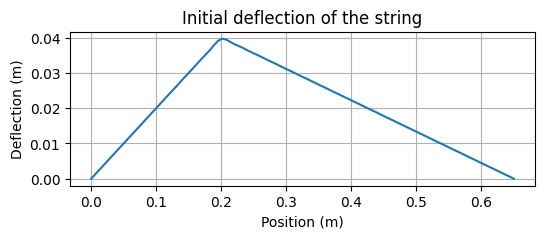

In [3]:
lambda_mu_str = string_eigenvalues(n_modes_str, string_params_nl.length)
wn_str = np.sqrt(lambda_mu_str)
grid_str = np.linspace(0, string_params_nl.length, n_gridpoints_str)
K_str = string_eigenfunctions(wn_str, grid_str)

u0_modal_str = create_pluck_modal(
    lambda_mu_str,
    pluck_position=excitation_position_str,
    initial_deflection=initial_deflection_str,
    string_length=string_params_nl.length,
)
u0_str = inverse_STL(K_str, u0_modal_str, string_params_nl.length)

fig_str, ax_str = plt.subplots(1, 1, figsize=(6, 2))
ax_str.plot(grid_str, u0_str)
ax_str.set_xlabel("Position (m)")
ax_str.set_ylabel("Deflection (m)")
ax_str.set_title("Initial deflection of the string")
ax_str.grid(True)
ax_str

Define the non-linear term and integrate in time

In [4]:
gamma2_mu_str = damping_term(string_params_nl, lambda_mu_str)
omega_mu_squared_str = stiffness_term(string_params_nl, lambda_mu_str)

string_tau = string_tau_with_density(string_params_nl)
string_norm = string_params_nl.length / 2

# include the norm and lambda_mu to make it more compact
string_tau = string_tau * lambda_mu_str / string_norm

nl_fn_str = make_tm_nl_fn(lambda_mu_str, string_tau)
_, modal_sol_str = solve_tf_ic(
    gamma2_mu_str,
    omega_mu_squared_str,
    u0=u0_modal_str,
    v0=jnp.zeros_like(u0_modal_str),
    dt=dt_str,
    n_steps=n_steps_str,
    nl_fn=nl_fn_str,
)

# transpose to have modes in the first dimension
modal_sol_str = modal_sol_str.T

print(modal_sol_str.shape)

(50, 44100)


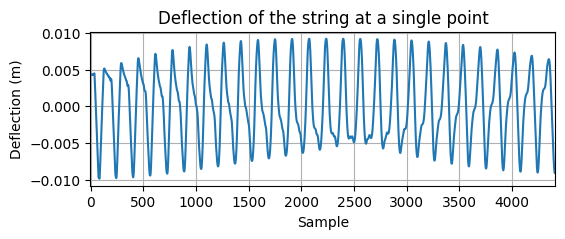

In [5]:
mu_str = np.arange(1, n_modes_str + 1)  # mode indices

readout_weights_str = evaluate_string_eigenfunctions(
    mu_str,
    readout_position_str,
    string_params_nl,
)

# at a single point
u_readout_str = readout_weights_str @ modal_sol_str

# at all points
sol_str = inverse_STL(K_str, modal_sol_str, string_params_nl.length)

audio_str = Audio(u_readout_str, rate=sample_rate_str)

fig_str_out, ax_str_out = plt.subplots(1, 1, figsize=(6, 2))
ax_str_out.plot(u_readout_str)
ax_str_out.set_xlabel("Sample")
ax_str_out.set_ylabel("Deflection (m)")
ax_str_out.set_title("Deflection of the string at a single point")
ax_str_out.set_xlim(-2, sample_rate_str // 10)
ax_str_out.grid(True)
ax_str_out

audio_str

## Tension modulated plate

The tension-modulated plate works just like the string we saw earlier, but with a slightly different factor:

\begin{equation}
\bar{f}_{nl} = \lambda_\mu q_{\mu} \left(\frac{E h}{2 L_x L_y (1 - \nu^2)}\right) \sum_{\mu} \frac{\lambda_{\mu} q_{\mu}^2}{||\Phi_{\mu}||^2}
\end{equation}

Define the parameters for the plate

In [6]:
n_modes_x_plate = 30
n_modes_y_plate = 30
n_modes_plate = 64
n_steps_plate = 44100
sample_rate_plate = 44100
dt_plate = 1.0 / sample_rate_plate
excitation_duration_plate = 1.0  # seconds
excitation_amplitude_plate = 100  # newtons
force_position_plate = (0.05, 0.05)
readout_position_tm_plate = (0.1, 0.1)
plate_params_tm = PlateParameters(
    Ts0=0.0,
    d1=0.0,
    d3=0.0019625,
    rho=7850,
    E=2e11,
    nu=0.3,
    l1=0.2,
    l2=0.3,
)

Get the eigenpairs and the excitation. We denote the retained eigenfunctions by $\phi_{\mu}(x,y)\equiv\phi_{\,m,n}(x,y)$ and gather them into the column vector

$$
\Phi(x,y)=\bigl[\phi_{1}(x,y),\ldots,\phi_{M}(x,y)\bigr]^{\mathsf T}\in\mathbb R^{M}.
$$

Evaluating this vector at the excitation and readout positions gives $\Phi_{\mathrm{ext}}$ and $\Phi_{\mathrm{read}}$, respectively.  A scalar point load $f_{\mathrm{ext}}^{\,n}$ applied at $(x_{\mathrm{ext}},y_{\mathrm{ext}})$ excites the modes producing the modal coordinate vector

$$
\mathbf{q}^{\,n}= \Phi_{\mathrm{ext}}\,f_{\mathrm{ext}}^{\,n}\in\mathbb R^{M},
$$

and the displacement measured at the readout location is reconstructed through

$$
w_{\mathrm{read}}^{\,n}= \frac{\Phi_{\mathrm{read}}^{\mathsf T}\mathbf{q}^{\,n}}
                               {\lVert \Phi\rVert^{2}} .
$$

where $n$ is the time step. For the rectangular plate $\lVert \Phi\rVert^{2} = \frac{L_x L_y}{4}$.

In [7]:
wnx_tm, wny_tm = plate_wavenumbers(
    n_modes_x_plate,
    n_modes_y_plate,
    plate_params_tm.l1,
    plate_params_tm.l2,
)
lambda_mu_2d_tm = plate_eigenvalues(wnx_tm, wny_tm)
n_gridpoints_x_tm = 101
n_gridpoints_y_tm = 151
x_tm = np.linspace(0, plate_params_tm.l1, n_gridpoints_x_tm)
y_tm = np.linspace(0, plate_params_tm.l2, n_gridpoints_y_tm)
K_tm = plate_eigenfunctions(wnx_tm, wny_tm, x_tm, y_tm)

kx_indices_tm, ky_indices_tm, lambda_mu_tm, sorted_indices_tm = (
    select_modes_from_eigenvalues(lambda_mu_2d_tm, n_modes_plate)
)
selected_indices_tm = np.stack([kx_indices_tm, ky_indices_tm], axis=-1)

rc_tm = create_1d_raised_cosine(
    duration=excitation_duration_plate,
    start_time=0.010,
    end_time=0.012,
    amplitude=excitation_amplitude_plate,
    sample_rate=sample_rate_plate,
)

weights_at_ex_tm = (
    evaluate_rectangular_eigenfunctions(
        selected_indices_tm,
        force_position_plate,
        params=plate_params_tm,
    )
    / plate_params_tm.density
)

weights_at_readout_tm = evaluate_rectangular_eigenfunctions(
    selected_indices_tm,
    readout_position_tm_plate,
    params=plate_params_tm,
)

modal_excitation_tm = np.outer(rc_tm, weights_at_ex_tm)

Define the non-linear term and integrate in time

In [8]:
omega_mu_squared_tm = stiffness_term(
    plate_params_tm,
    lambda_mu_tm,
)

gamma2_mu_tm = damping_term(
    plate_params_tm,
    np.sqrt(omega_mu_squared_tm),
)

plate_tau = (plate_params_tm.E * plate_params_tm.h) / (
    2 * plate_params_tm.l1 * plate_params_tm.l2 * (1 - plate_params_tm.nu**2)
)
plate_tau = plate_tau / plate_params_tm.density
plate_norm = 0.25 * plate_params_tm.l1 * plate_params_tm.l2

plate_tau = plate_tau * lambda_mu_tm / plate_norm

nl_fn_tm = make_tm_nl_fn(lambda_mu_tm, plate_tau)

_, modal_sol_tm = solve_tf_excitation(
    gamma2_mu_tm,
    omega_mu_squared_tm,
    modal_excitation_tm,
    dt_plate,
    nl_fn=nl_fn_tm,
)

modal_sol_tm = modal_sol_tm.T

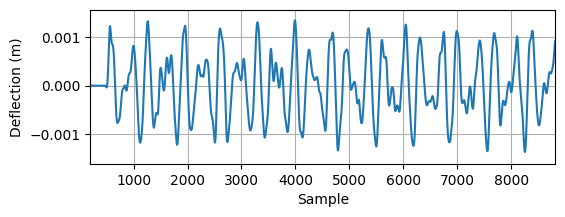

In [9]:
sol_tm = weights_at_readout_tm @ modal_sol_tm / plate_norm

fig_tm, ax_tm = plt.subplots(1, 1, figsize=(6, 2))
ax_tm.plot(sol_tm)
ax_tm.grid(True)
ax_tm.set_xlabel("Sample")
ax_tm.set_ylabel("Deflection (m)")
ax_tm.set_xlim(200, 4410 * 2)

sol_vel_tm = jnp.diff(sol_tm)
audio_tm = Audio(sol_vel_tm, rate=sample_rate_plate)
ax_tm
audio_tm

## Von Karman plate

In the Von Karman plate we have a different non-linear term:

\begin{equation}
\bar{f}_{nl} = \frac{E}{2 \rho ||\Phi||^2} \sum_{p, q, r}^n \frac{H_{q, r}^n C_{p, n}^s}{\zeta_n^4} q_p q_q q_r,
\end{equation}

We will use the same parameters as in the tension-modulated plate above but now we need the coupling coefficients (assuming simply supported boundary conditions). Calculating the coupling coefficients can take a while, so we will only use 10 in-plane modes and all transverse modes.

In [10]:
n_psi = 10  # only 10 in-plane modes
n_phi = n_modes_plate  # all transverse modes

indices_vk = np.argsort(lambda_mu_2d_tm.ravel())[:n_modes_plate]
ky_indices_vk, kx_indices_vk = np.unravel_index(indices_vk, lambda_mu_2d_tm.shape)
ky_indices_vk, kx_indices_vk = ky_indices_vk + 1, kx_indices_vk + 1
selected_indices_vk = np.stack([kx_indices_vk, ky_indices_vk], axis=-1)
lambda_mu_vk = lambda_mu_2d_tm.ravel()[indices_vk]

H0, H1, H2 = compute_coupling_matrix(
    n_psi,
    n_phi,
    plate_params_tm.l1,
    plate_params_tm.l2,
    kx_indices_vk,
    ky_indices_vk,
)

In [11]:
scale = plate_params_tm.E / (2 * plate_params_tm.rho * plate_norm)
H1_scaled = jnp.array(H1 * jnp.sqrt(scale))

Integrate in time. This is fast however with more modes it will take longer. In any case, this will take longer than the tension-modulated plate.

In [12]:
gamma2_mu_vk = damping_term(
    plate_params_tm,
    lambda_mu_vk,
)
omega_mu_squared_vk = stiffness_term(
    plate_params_tm,
    lambda_mu_vk,
)

nl_fn_vk = make_vk_nl_fn(H1_scaled)

_, modal_sol_vk = solve_tf_excitation(
    gamma2_mu_vk,
    omega_mu_squared_vk,
    modal_excitation_tm,
    dt_plate,
    nl_fn=nl_fn_vk,
)

modal_sol_vk = modal_sol_vk.T

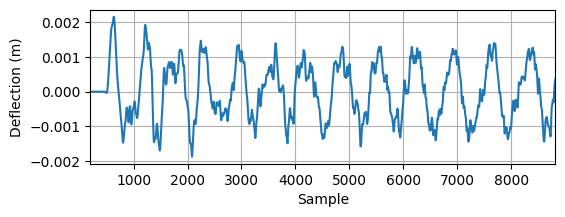

In [13]:
sol_vk = weights_at_readout_tm @ modal_sol_vk / plate_norm
sol_vel_vk = jnp.diff(sol_vk)

fig_vk, ax_vk = plt.subplots(1, 1, figsize=(6, 2))
ax_vk.plot(sol_vk)
ax_vk.grid(True)
ax_vk.set_xlabel("Sample")
ax_vk.set_ylabel("Deflection (m)")
ax_vk.set_xlim(200, 4410 * 2)

audio_vk = Audio(sol_vel_vk, rate=sample_rate_plate)
ax_vk
audio_vk